# Regresión Logistica

Construyamos un modelo a partir de Regresion Logistica para definir tendencias de permanencia en consumidores de una empresa de telecomunicaciones, <br> es importante notar que en este caso estaremos prediciendo la pertenencia a una de dos clases (clasificacion binaria) de la variable objetivo *churn* con valores [0,1]

## SETUP


In [2]:
#Descargamos librerias
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

#Importamos librerias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

%matplotlib inline 

import warnings
warnings.filterwarnings('ignore')

#Descargamos y leemos dataset

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"
churn_df = pd.read_csv(url)


## Estudio y Procesamiento del Dataset

Veamos un poco el esquema de nuestro dataset, a fin de identificar factores clave para nuestro analisis, así como para descartar otros features que quizas <br> no sean tan relevantes para nuestro modelo.

In [ ]:
# Imprimimos esquema del dataset con algunos ejemplos
churn_df.sample(3)

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
98,62.0,76.0,20.0,35.0,3.0,18.0,0.0,1.0,0.0,17.25,...,0.0,0.0,0.0,0.0,1.0,2.848,3.240,3.555,2.0,0.0
127,10.0,40.0,6.0,22.0,3.0,6.0,0.0,0.0,0.0,5.05,...,0.0,1.0,0.0,0.0,0.0,1.619,3.240,3.091,1.0,1.0
154,60.0,53.0,22.0,171.0,1.0,37.0,0.0,1.0,0.0,9.90,...,0.0,0.0,1.0,1.0,0.0,2.293,3.458,5.142,3.0,0.0


Podemos observar que hay distintos datos en nuestra base que no parecerían ser del todo relevantes, además nuestro modelo va a predecir el *churn* 
<br> (si un cliente deja de hacer negocios con la empresa) y scikit necesita que la variable objetivo sea de tipo entero, entonces debemos modificarlo. <br> Por último vamos a normalizar los valores de nuestros features para llevarlos a una misma escala.

In [11]:
# Elejimos variables a utilizar como features
churn_df = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'churn']]
X = np.asarray(churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']])

#Modificamos el tipo de la variable objetivo a int
churn_df['churn'] = churn_df['churn'].astype('int')
y = np.asarray(churn_df["churn"])

#Normalizamos valores
X_norm = StandardScaler().fit(X).transform(X)

## Modelado

Finalmente podemos comenzar a armar nuestro modelo, para ello debemos separar nuestro dataset en entrenamiento | validacion y entrenar al modelo de Regresion Logistica 

In [ ]:
# Separamos en 20% test , 80% entrenamiento
X_train, X_test, y_train, y_test = train_test_split( X_norm, y, test_size=0.2, random_state=4)

# Entrenamos al modelo
LR = LogisticRegression().fit(X_train,y_train)


Una vez entrenado el modelo, podemos testear su desempeño y obtener *insights* sobre el peso que tiene cada feature en la toma de decisiones sobre la clase binaria, <br>
una observacion fundamental es que la regresion logistica se basa en asignaciones probabilisticas de pertenencia a clases, en otras palabras: <br> Nuestro modelo indicara las probabilidades de que un elmento pertenezca a la clase 1 o 0 y luego -segun el Threshold del modelo- se asignara la clase predominante. 

In [14]:
yhat = LR.predict(X_test)
print(f"Accuracy Ratio: {np.mean(yhat == y_test):.2%}")

Accuracy Ratio: 72.50%


Teniendo una primera vista de la precision de nuestro modelo podriamos estar interesados en ver cuales features fueron particularmente <br> influyentes en la toma de decisiones, podemos visualizar los pesos (o coeficientes) de cada feature, a mayor valor mas impacto tiene en la clasificacion positiva. 

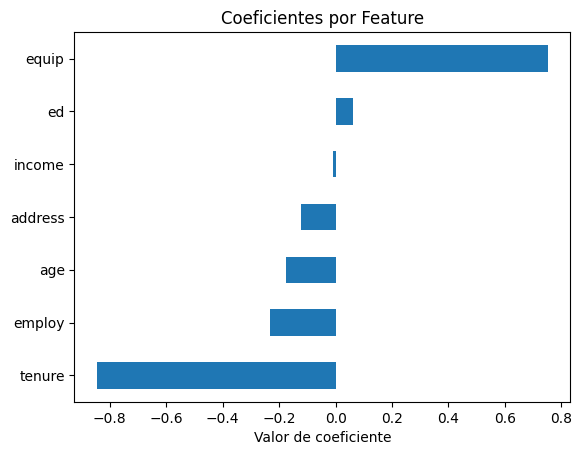

In [17]:
#Calculamos peso/coeficiente de cada feature 
coefficients = pd.Series(LR.coef_[0], index=churn_df.columns[:-1])
coefficients.sort_values().plot(kind='barh')
plt.title("Coeficientes por Feature")
plt.xlabel("Valor de coeficiente")
plt.show()